In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Input, Reshape, multiply
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# SE block definition
def se_block(input_tensor, reduction=16):
    channels = input_tensor.shape[-1]
    se = GlobalAveragePooling2D()(input_tensor)
    se = Reshape((1, 1, channels))(se)
    se = Dense(channels // reduction, activation='relu')(se)
    se = Dense(channels, activation='sigmoid')(se)
    return multiply([input_tensor, se])

# Paths to your dataset
base_dir = r'C:\Users\KIIT\Desktop\malaria'

# Image Data Generators with enhanced Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    shear_range=0.2,
    zoom_range=0.2,  # Reduced zoom for finer adjustments
    rotation_range=20,  # Reduced rotation
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]  # New brightness adjustment
)

val_datagen = ImageDataGenerator(rescale=1.0/255)

# Load images from directory structure
train_generator = train_datagen.flow_from_directory(
    directory=f'{base_dir}/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    directory=f'{base_dir}/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# Build the Model with Xception Base
base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the first 50 layers for better flexibility
for layer in base_model.layers[:50]:
    layer.trainable = False

# Build the new model
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)

# Insert SE block after the Xception base
x = se_block(x)

# Global Average Pooling and Classifier
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

# Complete model
model = Model(inputs, outputs)

# Compile with fixed learning rate for stable training
initial_learning_rate = 1e-4  # Adjusted for finer control
model.compile(optimizer=Adam(learning_rate=initial_learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])
5
# Define Callbacks with adjusted parameters
early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Train the Model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=20,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping, reduce_lr]
)


Found 22048 images belonging to 2 classes.
Found 2755 images belonging to 2 classes.
Epoch 1/20


C:\Users\KIIT\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


689/689 ━━━━━━━━━━━━━━━━━━━━ 4430s 6s/step - accuracy: 0.8744 - loss: 0.7901 - val_accuracy: 0.9669 - val_loss: 0.5285 - learning_rate: 1.0000e-04
Epoch 2/20


C:\Users\KIIT\anaconda3\Lib\contextlib.py:155: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.4089 - learning_rate: 1.0000e-04
Epoch 3/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 4419s 6s/step - accuracy: 0.9325 - loss: 0.5968 - val_accuracy: 0.9688 - val_loss: 0.4593 - learning_rate: 1.0000e-04
Epoch 4/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 404us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.3739 - learning_rate: 1.0000e-04
Epoch 5/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 4538s 7s/step - accuracy: 0.9480 - loss: 0.5030 - val_accuracy: 0.9669 - val_loss: 0.4154 - learning_rate: 1.0000e-04
Epoch 6/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.3182 - learning_rate: 1.0000e-04
Epoch 7/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 4424s 6s/step - accuracy: 0.9518 - loss: 0.4538 - val_accuracy: 0.9717 - val_loss: 0.3582 - learning_rate: 1.0000e-04
Epoch 8/20
689/689 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Epoch 11/20
# 252/689 ━━━━━━━━━━━━━━━━━━━━ 47:07 6s/step - accuracy: 0.9577 - loss: 0.3553

Found 2755 images belonging to 2 classes.


C:\Users\KIIT\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


87/87 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.9675 - loss: 0.1562
Test Accuracy: 96.73%
87/87 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step


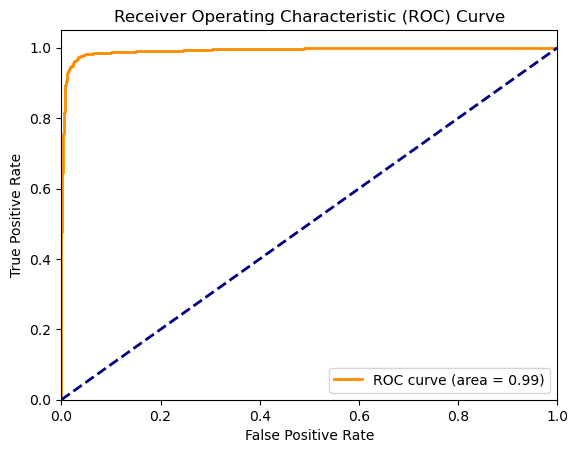

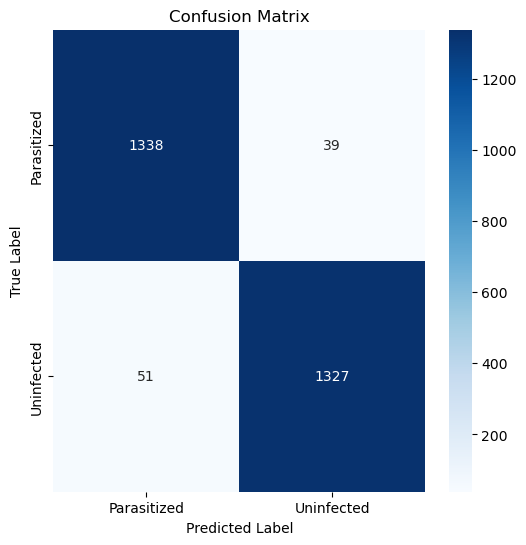


Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.96      0.97      0.97      1377
  Uninfected       0.97      0.96      0.97      1378

    accuracy                           0.97      2755
   macro avg       0.97      0.97      0.97      2755
weighted avg       0.97      0.97      0.97      2755



In [2]:
# to run nxt



import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Test Data Generator
test_datagen = ImageDataGenerator(rescale=1.0/255)

test_generator = test_datagen.flow_from_directory(
    directory=f'{base_dir}/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # Important to keep order for evaluation
)

# Step 1: Evaluate Model on Test Set
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Step 2: Get Predictions and True Labels
y_true = test_generator.classes
y_pred_prob = model.predict(test_generator, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # Convert probabilities to binary predictions

# Step 3: ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Step 4: Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Parasitized', 'Uninfected'], yticklabels=['Parasitized', 'Uninfected'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification Report for additional metrics
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Parasitized', 'Uninfected']))
